# Model Evaluation & Comparison

Compare our ML models vs baselines and report accuracy metrics.

## 1. Travel Time Model

In [9]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def mae(y_true, y_pred): return np.abs(y_true - y_pred).mean()
def rmse(y_true, y_pred): return np.sqrt(((y_true - y_pred)**2).mean())
def mape(y_true, y_pred): return (np.abs((y_true - y_pred) / (y_true + 1e-8)) * 100).mean()
def accuracy_within_pct(y_true, y_pred, pct=10): return (np.abs(y_pred - y_true) / (y_true + 1e-8) <= pct/100).mean() * 100

df = pd.read_csv("../data/raw/travel_times.csv")
df["is_rush"] = ((df["hour"] >= 7) & (df["hour"] <= 9)) | ((df["hour"] >= 17) & (df["hour"] <= 20))
df["is_rush"] = df["is_rush"].astype(int)
_, test = train_test_split(df, test_size=0.2, random_state=42)
X_test = test[["distance_km", "hour", "day_of_week", "is_rush"]].copy()
y_true = test["duration_min"].values

model = joblib.load("../models/travel_time_model.joblib")
y_pred_ml = model.predict(X_test)

avg_speed = df["distance_km"].sum() / df["duration_min"].sum()
y_pred_naive = test["distance_km"].values / avg_speed

report = {}
acc_ml = accuracy_within_pct(y_true, y_pred_ml, 10)
acc_base = accuracy_within_pct(y_true, y_pred_naive, 10)
report["travel_time"] = {
    "mae_ml": float(mae(y_true, y_pred_ml)), "mae_baseline": float(mae(y_true, y_pred_naive)),
    "r2_ml": float(r2_score(y_true, y_pred_ml)), "r2_baseline": float(r2_score(y_true, y_pred_naive)),
    "accuracy_pct": float(acc_ml), "accuracy_baseline_pct": float(acc_base),
    "n_test": len(test), "unit": "min", "improvement_pct": float((1 - mae(y_true, y_pred_ml)/mae(y_true, y_pred_naive))*100),
    "note": "ML adds hour/day_of_week - captures time-of-day effects vs static distance/speed"
}

print("=== Travel Time ===")
print(f"Our ML model  - MAE: {mae(y_true, y_pred_ml):.2f} min  RMSE: {rmse(y_true, y_pred_ml):.2f}  R²: {r2_score(y_true, y_pred_ml):.3f}  Accuracy (within 10%): {acc_ml:.1f}%")
print(f"Naive (dist/speed) - MAE: {mae(y_true, y_pred_naive):.2f} min  R²: {r2_score(y_true, y_pred_naive):.3f}  Accuracy: {acc_base:.1f}%")
pct = (1 - mae(y_true, y_pred_ml)/mae(y_true, y_pred_naive))*100
print(f"\n→ ML is {abs(pct):.1f}% {'better' if pct > 0 else 'worse'} than naive baseline (n={len(test)})")

# Distance-bucket breakdown
test_copy = test.copy()
test_copy["pred_ml"] = y_pred_ml
test_copy["bucket"] = pd.cut(test_copy["distance_km"], bins=[0, 5, 15, 100], labels=["short (0-5km)", "medium (5-15km)", "long (15+km)"])
print("\nMAE by distance bucket:")
for b in ["short (0-5km)", "medium (5-15km)", "long (15+km)"]:
    m = test_copy[test_copy["bucket"]==b]
    if len(m) > 0:
        print(f"  {b}: MAE={mae(m['duration_min'], m['pred_ml']):.2f} min (n={len(m)})")

=== Travel Time ===
Our ML model  - MAE: 0.75 min  RMSE: 0.99  R²: 0.978  Accuracy (within 10%): 75.9%
Naive (dist/speed) - MAE: 1.44 min  R²: 0.930  Accuracy: 51.3%

→ ML is 48.4% better than naive baseline (n=191)

MAE by distance bucket:
  short (0-5km): MAE=0.49 min (n=21)
  medium (5-15km): MAE=0.79 min (n=92)
  long (15+km): MAE=0.77 min (n=78)


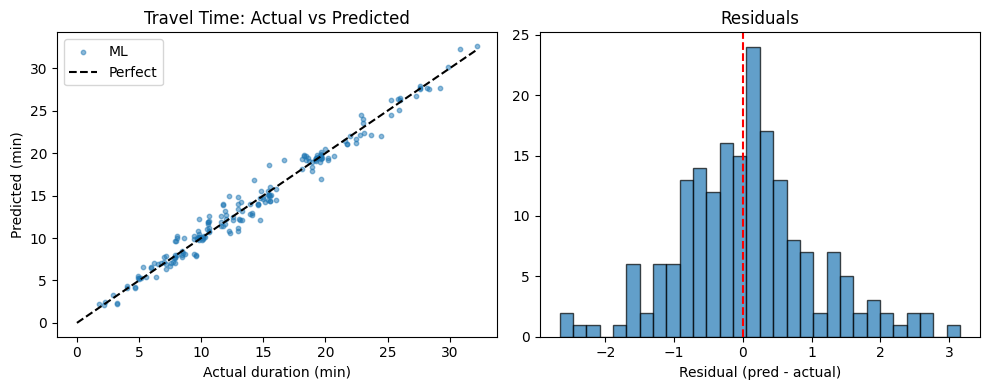

In [10]:
# Travel time: actual vs predicted
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_true, y_pred_ml, alpha=0.5, s=10, label="ML")
axes[0].plot([0, y_true.max()], [0, y_true.max()], "k--", label="Perfect")
axes[0].set_xlabel("Actual duration (min)"); axes[0].set_ylabel("Predicted (min)")
axes[0].set_title("Travel Time: Actual vs Predicted"); axes[0].legend()
axes[1].hist(y_pred_ml - y_true, bins=30, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--"); axes[1].set_xlabel("Residual (pred - actual)")
axes[1].set_title("Residuals")
Path("../docs/charts").mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig("../docs/charts/travel_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

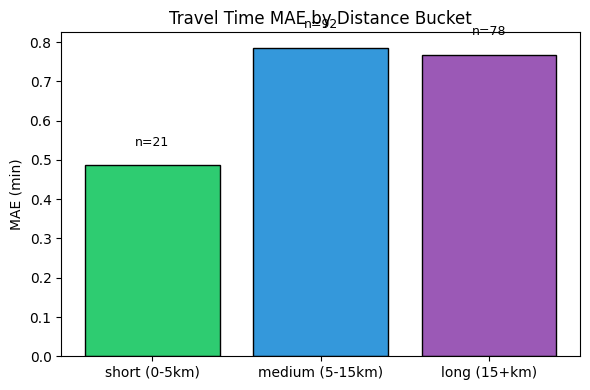

In [11]:
# Travel time: MAE by distance bucket (bar chart for research)
fig, ax = plt.subplots(figsize=(6, 4))
buckets = ["short (0-5km)", "medium (5-15km)", "long (15+km)"]
maes = []
counts = []
for b in buckets:
    m = test_copy[test_copy["bucket"] == b]
    if len(m) > 0:
        maes.append(mae(m["duration_min"], m["pred_ml"]))
        counts.append(len(m))
    else:
        maes.append(0)
        counts.append(0)
x = np.arange(len(buckets))
bars = ax.bar(x, maes, color=["#2ecc71", "#3498db", "#9b59b6"], edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.set_ylabel("MAE (min)")
ax.set_title("Travel Time MAE by Distance Bucket")
for i, (b, c) in enumerate(zip(bars, counts)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05, f"n={c}", ha="center", fontsize=9)
Path("../docs/charts").mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig("../docs/charts/travel_mae_by_bucket.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Pricing Model

In [12]:
df = pd.read_csv("../data/raw/pricing_synthetic.csv")
_, test = train_test_split(df, test_size=0.2, random_state=42)
meta = joblib.load("../models/urgency_encoder.joblib")
le = meta["encoder"]
test = test.copy()
test["urgency_enc"] = le.transform(test["urgency"])
X_test = test[["distance_km", "weight_kg", "volume_l", "urgency_enc", "hour", "day_of_week", "demand_score"]]
y_true = test["price"].values

model = joblib.load("../models/pricing_model.joblib")
y_pred_ml = model.predict(X_test)

# Baseline: distance-only (fairer - doesn't use the exact formula that generated the data)
avg_km_rate = df["price"].mean() / (df["distance_km"].mean() + 1)
y_pred_baseline = 50 + test["distance_km"].values * avg_km_rate
y_pred_baseline = np.clip(y_pred_baseline, 80, None)

mae_ml, mae_base = mae(y_true, y_pred_ml), mae(y_true, y_pred_baseline)
pct = (1 - mae_ml/mae_base) * 100
acc_ml = accuracy_within_pct(y_true, y_pred_ml, 10)
acc_base = accuracy_within_pct(y_true, y_pred_baseline, 10)
report["pricing"] = {
    "mae_ml": float(mae_ml), "mae_baseline": float(mae_base),
    "r2_ml": float(r2_score(y_true, y_pred_ml)), "r2_baseline": float(r2_score(y_true, y_pred_baseline)),
    "accuracy_pct": float(acc_ml), "accuracy_baseline_pct": float(acc_base),
    "n_test": len(test), "unit": "INR", "improvement_pct": float(pct),
    "note": "Baseline = distance-only. With real data, ML can learn demand/urgency patterns."
}

print("=== Pricing ===")
print(f"Our ML model  - MAE: {mae_ml:.2f} INR  R²: {r2_score(y_true, y_pred_ml):.3f}  Accuracy (within 10%): {acc_ml:.1f}%")
print(f"Baseline (distance-only) - MAE: {mae_base:.2f} INR  R²: {r2_score(y_true, y_pred_baseline):.3f}  Accuracy: {acc_base:.1f}%")
print(f"\n→ ML is {abs(pct):.1f}% {'better' if pct > 0 else 'worse'} than baseline (n={len(test)})")

=== Pricing ===
Our ML model  - MAE: 16.32 INR  R²: 0.995  Accuracy (within 10%): 96.3%
Baseline (distance-only) - MAE: 172.40 INR  R²: 0.448  Accuracy: 17.2%

→ ML is 90.5% better than baseline (n=1000)


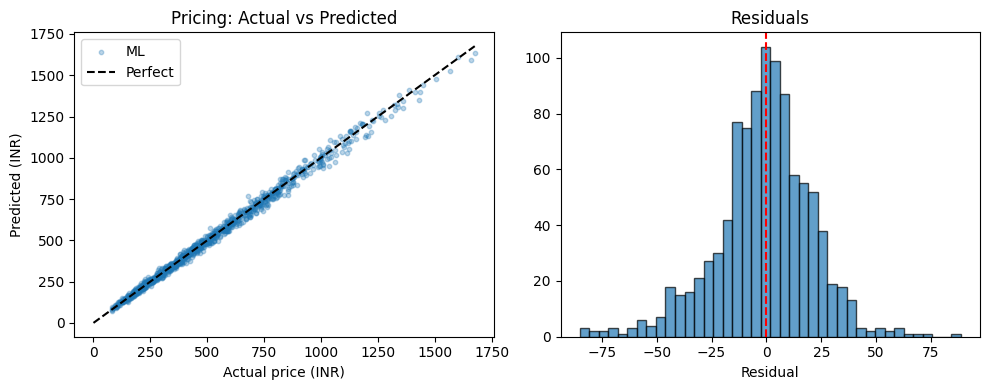

In [13]:
# Pricing: actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_true, y_pred_ml, alpha=0.3, s=10, label="ML")
axes[0].plot([0, y_true.max()], [0, y_true.max()], "k--", label="Perfect")
axes[0].set_xlabel("Actual price (INR)"); axes[0].set_ylabel("Predicted (INR)")
axes[0].set_title("Pricing: Actual vs Predicted"); axes[0].legend()
axes[1].hist(y_pred_ml - y_true, bins=40, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--"); axes[1].set_xlabel("Residual"); axes[1].set_title("Residuals")
Path("../docs/charts").mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig("../docs/charts/pricing_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

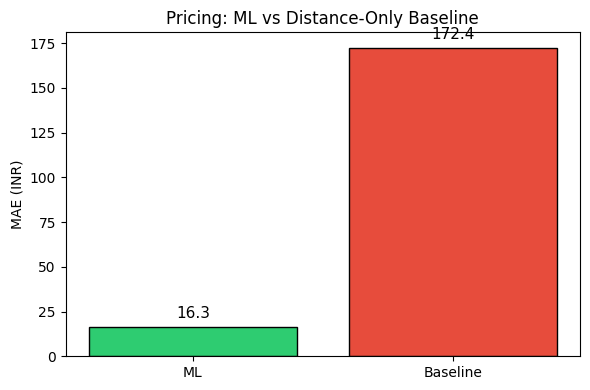

In [14]:
# Pricing: ML vs Baseline comparison (bar chart for research)
fig, ax = plt.subplots(figsize=(6, 4))
models = ["ML", "Baseline"]
maes = [mae_ml, mae_base]
colors = ["#2ecc71", "#e74c3c"]
bars = ax.bar(models, maes, color=colors, edgecolor="black")
ax.set_ylabel("MAE (INR)")
ax.set_title("Pricing: ML vs Distance-Only Baseline")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f"{b.get_height():.1f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("../docs/charts/pricing_ml_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Demand Forecasting

In [15]:
df = pd.read_csv("../data/raw/travel_times.csv")
city = df.groupby(["hour", "day_of_week"]).size().reset_index(name="count")
city["hour_sin"] = np.sin(2 * np.pi * city["hour"] / 24)
city["hour_cos"] = np.cos(2 * np.pi * city["hour"] / 24)
city["is_rush"] = ((city["hour"] >= 7) & (city["hour"] <= 9)) | ((city["hour"] >= 17) & (city["hour"] <= 20))
city["is_rush"] = city["is_rush"].astype(int)
train_city, test = train_test_split(city, test_size=0.2, random_state=42)
X_test = test[["hour", "day_of_week", "hour_sin", "hour_cos", "is_rush"]]
y_true = test["count"].values

model = joblib.load("../models/demand_model.joblib")
y_pred_ml = model.predict(X_test)

# Baseline: median per (hour, dow) from TRAIN ONLY (no leakage)
medians = train_city.groupby(["hour", "day_of_week"])["count"].median()
global_med = train_city["count"].median()
y_pred_baseline = np.array([medians.get((int(h), int(d)), global_med) for h, d in zip(test["hour"], test["day_of_week"])])

mae_ml, mae_base = mae(y_true, y_pred_ml), mae(y_true, y_pred_baseline)
pct = (1 - mae_ml/mae_base) * 100
acc_ml = accuracy_within_pct(y_true, y_pred_ml, 20)
acc_base = accuracy_within_pct(y_true, y_pred_baseline, 20)
report["demand"] = {
    "mae_ml": float(mae_ml), "mae_baseline": float(mae_base),
    "r2_ml": float(r2_score(y_true, y_pred_ml)), "r2_baseline": float(r2_score(y_true, y_pred_baseline)),
    "accuracy_pct": float(acc_ml), "accuracy_baseline_pct": float(acc_base),
    "n_test": len(test), "unit": "requests", "improvement_pct": float(pct),
    "note": "LightGBM + cyclic hour + is_rush. Accuracy = % within 20% of actual (small counts)."
}

print("=== Demand Forecast ===")
print(f"Our ML model  - MAE: {mae_ml:.2f}  R²: {r2_score(y_true, y_pred_ml):.3f}  Accuracy (within 20%): {acc_ml:.1f}%")
print(f"Baseline (median) - MAE: {mae_base:.2f}  R²: {r2_score(y_true, y_pred_baseline):.3f}  Accuracy: {acc_base:.1f}%")
print(f"\n→ ML is {abs(pct):.1f}% {'better' if pct > 0 else 'worse'} than baseline (n={len(test)})")

=== Demand Forecast ===
Our ML model  - MAE: 1.76  R²: 0.191  Accuracy (within 20%): 29.4%
Baseline (median) - MAE: 1.85  R²: -0.006  Accuracy: 35.3%

→ ML is 4.9% better than baseline (n=34)


### Visualization (demand)

## 4. Hotspots Quality

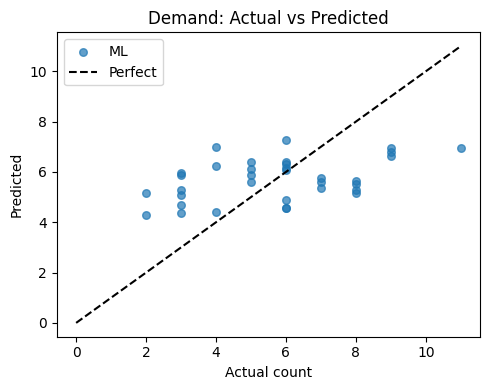

In [16]:
# Demand: actual vs predicted
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_true, y_pred_ml, alpha=0.7, s=30, label="ML")
ax.plot([0, y_true.max()], [0, y_true.max()], "k--", label="Perfect")
ax.set_xlabel("Actual count"); ax.set_ylabel("Predicted"); ax.set_title("Demand: Actual vs Predicted")
Path("../docs/charts").mkdir(parents=True, exist_ok=True)
ax.legend(); plt.tight_layout()
plt.savefig("../docs/charts/demand_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/raw/travel_times.csv")
points = pd.concat([
    df[["origin_lat", "origin_lng"]].rename(columns={"origin_lat":"lat", "origin_lng":"lng"}),
    df[["dest_lat", "dest_lng"]].rename(columns={"dest_lat":"lat", "dest_lng":"lng"})
])
X = points[["lat", "lng"]]

hotspots = joblib.load("../models/hotspots.joblib")
kmeans = KMeans(n_clusters=len(hotspots), random_state=42, n_init=10).fit(X)
silhouette = silhouette_score(X, kmeans.labels_)

report["hotspots"] = {"silhouette": float(silhouette), "n_clusters": len(hotspots), "n_points": len(X), "note": "0.5+ = good separation"}
print("=== Hotspots ===")
print(f"Silhouette score: {silhouette:.3f} (higher = tighter, well-separated clusters; range -1 to 1)")
print(f"Coverage: {len(hotspots)} hotspots across Mumbai")

=== Hotspots ===
Silhouette score: 0.758 (higher = tighter, well-separated clusters; range -1 to 1)
Coverage: 10 hotspots across Mumbai


## 5. Summary Report

In [18]:
import json

# Add human-readable vs baseline summary to report
for name, r in report.items():
    imp = r.get("improvement_pct")
    if imp is not None:
        r["vs_baseline"] = f"{abs(imp):.1f}% {'better' if imp > 0 else 'worse'} than baseline"
Path("../docs").mkdir(exist_ok=True)
with open("../docs/evaluation_report.json", "w") as f:
    json.dump(report, f, indent=2)

print("Report saved to docs/evaluation_report.json\n")
print("=== Accuracy Summary (ML vs baseline / naive) ===")
for name, r in report.items():
    if "accuracy_pct" in r:
        b = r.get("accuracy_baseline_pct", "-")
        bstr = f"{b:.1f}%" if isinstance(b, (int, float)) else str(b)
        imp = r.get("improvement_pct")
        vs = f"  → {abs(imp):.1f}% {'better' if imp > 0 else 'worse'} than baseline (by MAE)" if imp is not None else ""
        print(f"  {name}: ML {r['accuracy_pct']:.1f}%  |  baseline {bstr}{vs}")
    elif "silhouette" in r:
        print(f"  {name}: quality {r['silhouette']:.2f} (silhouette)")
print("\nFull report:")
print(json.dumps(report, indent=2))

Report saved to docs/evaluation_report.json

=== Accuracy Summary (ML vs baseline / naive) ===
  travel_time: ML 75.9%  |  baseline 51.3%  → 48.4% better than baseline (by MAE)
  pricing: ML 96.3%  |  baseline 17.2%  → 90.5% better than baseline (by MAE)
  demand: ML 29.4%  |  baseline 35.3%  → 4.9% better than baseline (by MAE)
  hotspots: quality 0.76 (silhouette)

Full report:
{
  "travel_time": {
    "mae_ml": 0.7452375744852091,
    "mae_baseline": 1.4449735995462458,
    "r2_ml": 0.9779004145796046,
    "r2_baseline": 0.9303434590436279,
    "accuracy_pct": 75.91623036649214,
    "accuracy_baseline_pct": 51.30890052356021,
    "n_test": 191,
    "unit": "min",
    "improvement_pct": 48.42552315701612,
    "note": "ML adds hour/day_of_week - captures time-of-day effects vs static distance/speed",
    "vs_baseline": "48.4% better than baseline"
  },
  "pricing": {
    "mae_ml": 16.32243282207696,
    "mae_baseline": 172.39989987828454,
    "r2_ml": 0.9946447678675836,
    "r2_basel

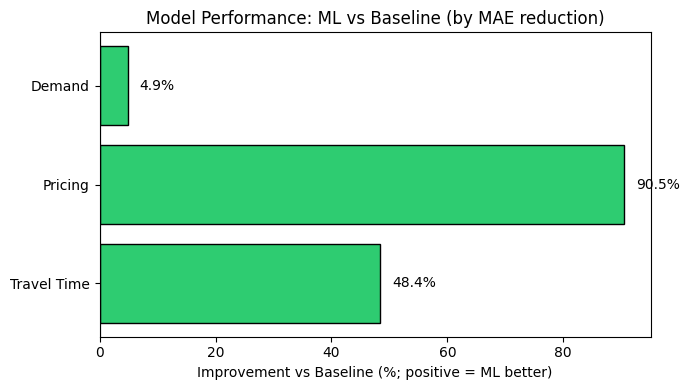

In [19]:
# Cross-model: ML vs Baseline improvement (MAE reduction %)
fig, ax = plt.subplots(figsize=(7, 4))
models_with_imp = [(k, r.get("improvement_pct")) for k, r in report.items() if r.get("improvement_pct") is not None]
labels = [m[0].replace("_", " ").title() for m in models_with_imp]
improvements = [m[1] for m in models_with_imp]
colors = ["#2ecc71" if imp > 0 else "#e74c3c" for imp in improvements]
bars = ax.barh(labels, improvements, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Improvement vs Baseline (%; positive = ML better)")
ax.set_title("Model Performance: ML vs Baseline (by MAE reduction)")
for b, imp in zip(bars, improvements):
    ax.text(imp + (2 if imp >= 0 else -8), b.get_y() + b.get_height()/2, f"{imp:.1f}%", va="center", fontsize=10)
plt.tight_layout()
Path("../docs/charts").mkdir(parents=True, exist_ok=True)
plt.savefig("../docs/charts/cross_model_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparing with External Services

To compare travel time with Google Maps / OpenRouteService:
1. Get API key from [OpenRouteService](https://openrouteservice.org/) (free tier)
2. Call their Directions API for same O/D pairs
3. Compare our ML duration vs their returned duration (they use live traffic in some modes)

For pricing: competitor data is rarely public. Use A/B testing in production.